In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(r'Cleaned_Data_HeartDisease.csv')

Saving Cleaned_Data_HeartDisease.csv to Cleaned_Data_HeartDisease.csv


In [3]:
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140.0,289,0,0,172,0,0.0,1,0
1,49,0,3,160.0,180,0,0,156,0,1.0,2,1
2,37,1,2,130.0,283,0,1,98,0,0.0,1,0
3,48,0,4,138.0,214,0,0,108,1,1.5,2,1
4,54,1,3,150.0,195,0,0,122,0,0.0,1,0


 Distribution of Heart Disease by Age

[]

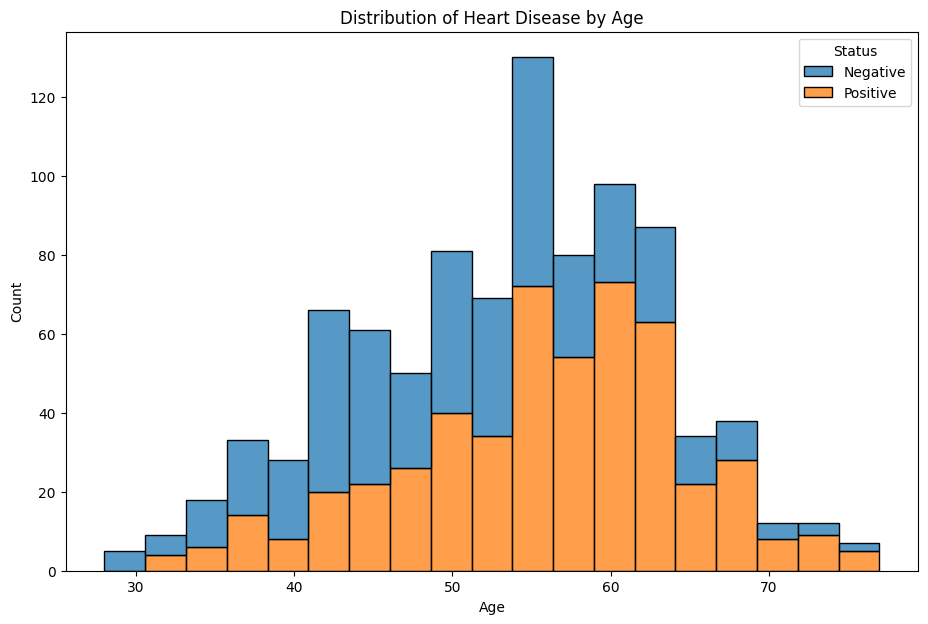

In [27]:


plt.figure(figsize=(11,7))

sns.histplot(data=df.assign(Status=df['target'].map({1: 'Positive', 0: 'Negative'})),
    x='age', hue='Status',  multiple='stack' )

plt.title("Distribution of Heart Disease by Age")
plt.xlabel("Age")

plt.plot()

In [5]:
## younger Age group (of age 30 to 35) has lower instances of heart disease
## Heart Disease gets common as the age increases peaking at the age of 55 to 65

Distribution of Heart Disease by Gender

/tmp/ipykernel_272/927510918.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex_Label', palette='Blues_d')


<Figure size 1000x600 with 0 Axes>

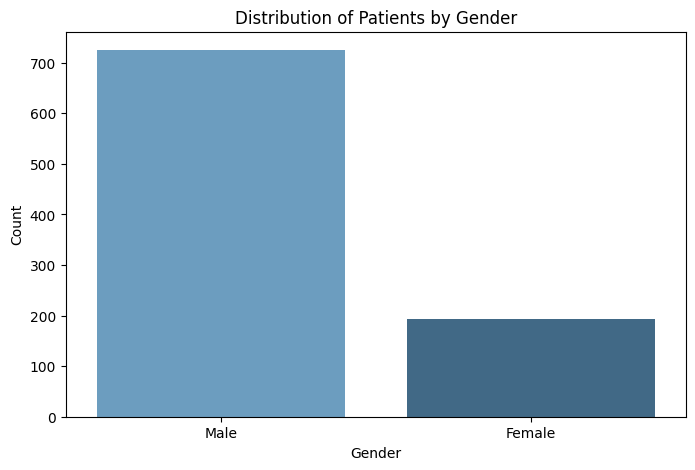

In [29]:
gender_map = {0: 'Female', 1: 'Male'}

df['Sex_Label'] = df['sex'].map(gender_map)

plt.figure(figsize=(10,6))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sex_Label', palette='Blues_d')
plt.title('Distribution of Patients by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [7]:
## Data shows Male has higher risk of having heart disease than female
## It's almost twice more than female

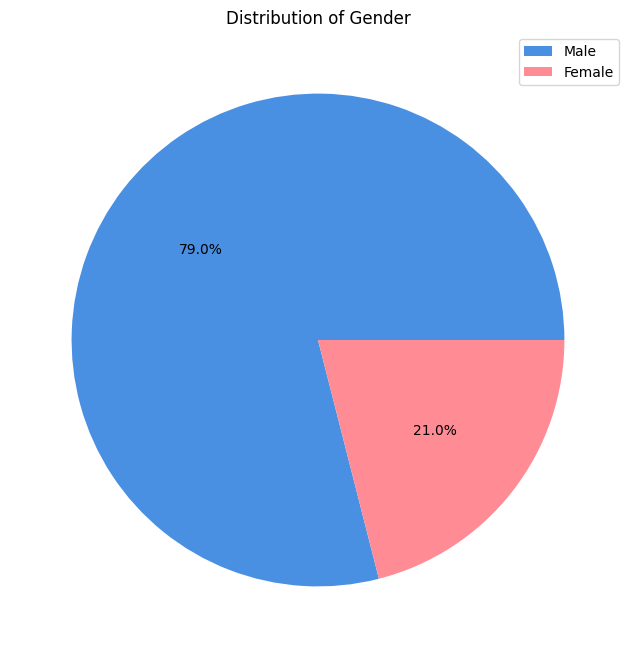

In [30]:
gender_counts = df['sex'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(gender_counts, autopct='%1.1f%%', colors=['#4A90E2', '#FF8C94'])
plt.title('Distribution of Gender')

plt.legend(['Male', 'Female'])


plt.show()

In [9]:
## Data shows Male has higher risk of having heart disease than female
## It's almost twice more than female

Correlation HeatMap

[]

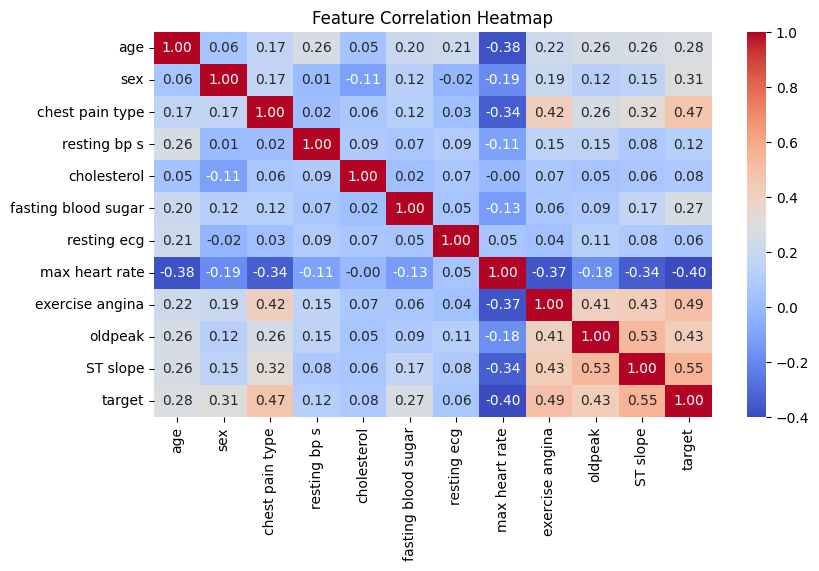

In [10]:
plt.figure(figsize=(9,5))

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')


plt.plot()

In [11]:
## ST slope (0.55) has the strongest positive correlation with target
## Exercise angina (0.49) & Chest pain type (0.47) also show a moderate positive correlation with the target.
## Cholesterol (0.08) & Resting ECG (0.06) are very close to zero, so these factors don't have a strong linear relationship with the target.

/tmp/ipykernel_272/867253374.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


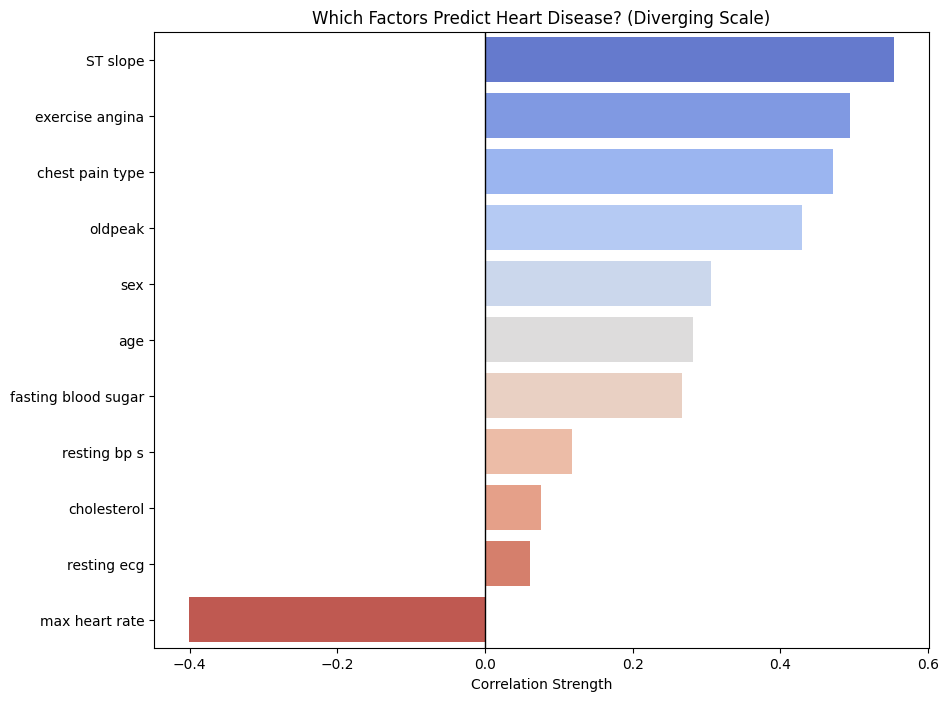

In [35]:
## 1. Calculate how everything correlates with target

correlations = df.select_dtypes(include=np.number).corr()['target'].sort_values(ascending=False).drop('target')

plt.figure(figsize=(10, 8))

sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

plt.axvline(0, color='black', lw=1)
plt.title('Which Factors Predict Heart Disease? (Diverging Scale)')
plt.xlabel('Correlation Strength')
plt.ylabel('')
plt.show()

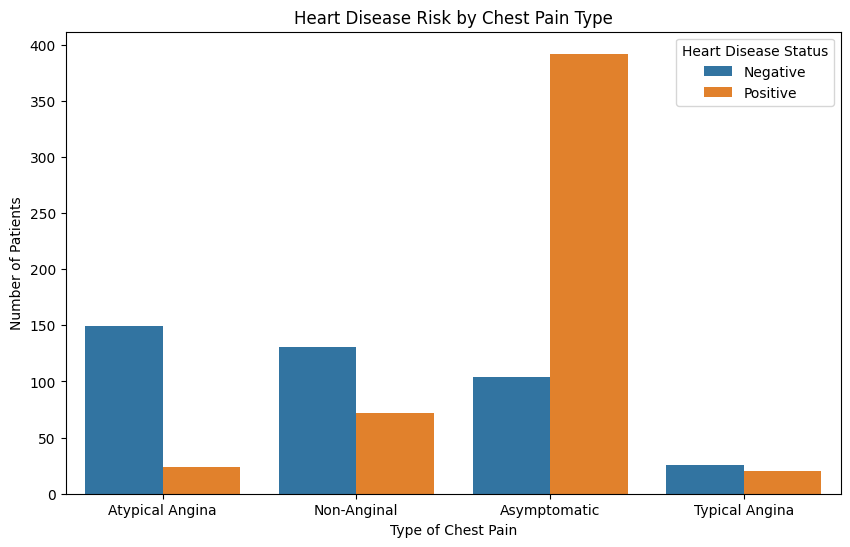

In [26]:

target_map = {0: 'Negative', 1: 'Positive'}
cp_map = {1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-Anginal', 4: 'Asymptomatic'}

df['Status'] = df['target'].map(target_map)
df['Chest_Pain_Label'] = df['chest pain type'].map(cp_map)


plt.figure(figsize=(10, 6))


sns.countplot(data=df, x='Chest_Pain_Label', hue='Status')
plt.title('Heart Disease Risk by Chest Pain Type')
plt.xlabel('Type of Chest Pain')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease Status')
plt.show()

In [14]:
## Chest Pain type 4( Asymptomatic) has higher chance of causing heart disease

Chest Pain Type and it's Meaning
1. Typical Angina (Value 1)
: This is "classic" heart-related chest pain. It usually feels like pressure or squeezing in the chest and is often
 triggered by physical activity or emotional stress.

2. Atypical Angina (Value 2)
: This is chest pain that might feel like heart pain but doesn't follow the "typical" pattern.
It might happen at rest or feel more like a sharp sensation rather than pressure.

3. Non-Anginal Pain (Value 3)
: This is chest pain that is likely not related to the heart. It is often described as "sharp" or "stabbing"
and can be caused by things like muscle strain or indigestion.

4. Asymptomatic (Value 4)
: This is the most critical one in the dataset. Asymptomatic means the patient feels no chest pain at all,
yet they may still have significant heart disease.
